In [ ]:
import pandas as pd
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import time
import asyncio
import httpx
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None


In [73]:
df=pd.read_csv("xydone.csv") # i cleaned the data from boliga, added postnumber and city(by), and area(område), region, and coordinates 
print(df.head())
print(df.shape)

   Købesum  Vær.  Byggeår        dato      stype     m2        btype  \
0  1398250     4     1956  27-05-2025  Fam. Salg   83.0   Fritidshus   
1  2620000     5     1972  27-05-2025  Alm. Salg  120.0     Rækkehus   
2  6450000     6     1906  27-05-2025  Alm. Salg  240.0  Landejendom   
3   460000     8     1908  27-05-2025      Andet  176.0        Villa   
4  2951000     5     1974  27-05-2025  Alm. Salg  143.0        Villa   

                    addresse  postnummer          by                  område  \
0  Nordmandsvej 12, Lyngsbæk        8400    Ebeltoft     Øst- og Midtjylland   
1           Rosenlyparken 80        2670       Greve  Hovedstaden, København   
2    Karlslunde Centervej 76        4030        Tune               Andre øer   
3              Hovedgaden 42        8763  Rask Mølle     Øst- og Midtjylland   
4             Kirkebakken 66        4621    Gadstrup               Andre øer   

     region                              full_address          x          y  
0   Jyll

In [ ]:
df['dato'] = pd.to_datetime(df['dato']) # im making date the index
df = df.sort_values('dato')
df = df.set_index('dato')

/var/folders/qr/zdl1jn496pg73658gxs99sxh0000gn/T/ipykernel_58317/453118314.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['dato'] = pd.to_datetime(df['dato'])


In [75]:
print(df.index)

DatetimeIndex(['1996-06-03', '1996-06-03', '1996-06-03', '1996-06-03',
               '1996-06-03', '1996-06-03', '1996-06-03', '1996-06-03',
               '1996-06-03', '1996-06-03',
               ...
               '2025-06-02', '2025-06-02', '2025-06-02', '2025-06-02',
               '2025-06-02', '2025-06-02', '2025-06-02', '2025-06-02',
               '2025-06-02', '2025-06-02'],
              dtype='datetime64[ns]', name='dato', length=1557121, freq=None)


In [ ]:
#here i get the rolling mean for price per square meter for different time windows and geographical areas
df['pris_pr_m2'] = df['Købesum'] / df['m2']


df = df.sort_index()

levels = ['by', 'postnummer', 'område', 'region']
time_windows = ['30D', '180D', '365D']

for level in levels:
    for window in time_windows:
        new_col_name = f'pris_pr_m2_mean_{window}_{level}'
        
        #calculates rolling mean for price per square meter
        df[new_col_name] = df.groupby(level)['pris_pr_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left', ).mean()
        ).fillna(0) #the first values will be nan, so we fill them with 0 we discard later
        print(f"Calculated {new_col_name}")



Calculated: pris_pr_m2_mean_30D_by
Calculated: pris_pr_m2_mean_180D_by
Calculated: pris_pr_m2_mean_365D_by
Calculated: pris_pr_m2_mean_30D_postnummer
Calculated: pris_pr_m2_mean_180D_postnummer
Calculated: pris_pr_m2_mean_365D_postnummer
Calculated: pris_pr_m2_mean_30D_område
Calculated: pris_pr_m2_mean_180D_område
Calculated: pris_pr_m2_mean_365D_område
Calculated: pris_pr_m2_mean_30D_region
Calculated: pris_pr_m2_mean_180D_region
Calculated: pris_pr_m2_mean_365D_region


In [8]:
df.tail(1000010)

,Købesum,Vær.,Byggeår,dato,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y
557111,8300000,6,1966,25-07-2019,Alm. Salg,203.0,Villa,"Lindevej 50, Hareskov",3500,Værløse,Nordsjælland,Sjælland,"Lindevej 50, Hareskov, 3500 Værløse",12.400434,55.761318
557112,3292500,3,1936,25-07-2019,Fam. Salg,80.0,Fritidshus,Skovdiget 7,3460,Birkerød,Nordsjælland,Sjælland,"Skovdiget 7, 3460 Birkerød",12.463998,55.863286
557113,698000,5,2020,25-07-2019,Alm. Salg,250.0,Villa,Sættravej 16,9300,Sæby,Nordjylland,Jylland,"Sættravej 16, 9300 Sæby",10.499687,57.323320
557114,800000,4,1939,25-07-2019,Alm. Salg,150.0,Villa,"Lynggårdsvej 10, Tversted",9881,Bindslev,Nordjylland,Jylland,"Lynggårdsvej 10, Tversted, 9881 Bindslev",10.177801,57.566894
557115,670000,2,1987,25-07-2019,Alm. Salg,62.0,Rækkehus,Bragesvej 170,4220,Korsør,Andre øer,Sjælland,"Bragesvej 170, 4220 Korsør",11.125971,55.345516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557116,310000,5,1840,03-06-1996,Alm. Salg,136.0,Villa,"Vedersøvej 3, Madum",6990,Ulfborg,Sydjylland,Jylland,"Vedersøvej 3, Madum, 6990 Ulfborg",8.256332,56.234477
1557117,2900000,7,1916,03-06-1996,Fam. Salg,160.0,Ejerlejlighed,"Åboulevarden 100, 1. th",8000,Aarhus C,Øst- og Midtjylland,Jylland,"Åboulevarden 100, 1. th, 8000 Aarhus C",10.201651,56.155831
1557118,90000,4,1966,03-06-1996,Alm. Salg,60.0,Fritidshus,Pirken 39,9240,Nibe,Nordjylland,Jylland,"Pirken 39, 9240 Nibe",9.686027,57.028113
1557119,187000,2,1937,03-06-1996,Fam. Salg,112.0,Fritidshus,Furrebyvej 4,9480,Løkken,Nordjylland,Jylland,"Furrebyvej 4, 9480 Løkken",9.719989,57.374061


In [10]:
df.to_csv("afterlag.csv")

In [78]:
df = pd.read_csv("afterlag.csv")
df = df.set_index('dato')
df.index = pd.to_datetime(df.index)
print(df.shape)

(1557121, 27)


In [79]:
df.tail(10)


,Købesum,Vær.,Byggeår,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-02,2160000,3,2009,Alm. Salg,99.0,Rækkehus,"Jenstrup Huse 55, Dalby",4690,Haslev,Andre øer,Sjælland,"Jenstrup Huse 55, Dalby, 4690 Haslev",12.072821,55.315874,21818.181818,17680.672269,14688.245640,17421.868237,17680.672269,14688.245640,17421.868237,23353.473537,20919.411665,21050.029911,33116.267567,34805.712814,35100.397527
2025-06-02,5174400,6,1966,Fam. Salg,194.0,Villa,Kildebakken 3,3520,Farum,Nordsjælland,Sjælland,"Kildebakken 3, 3520 Farum",12.396829,55.809643,26672.164948,37459.977199,36726.253864,35478.545635,37459.977199,36726.253864,35478.545635,29962.022703,31113.569905,32278.285549,33116.267567,34805.712814,35100.397527
2025-06-02,1762000,4,1978,Alm. Salg,139.0,Villa,Sandbypark Alle 2,4171,Glumsø,Andre øer,Sjælland,"Sandbypark Alle 2, 4171 Glumsø",11.745717,55.379424,12676.258993,29000.000000,18820.104250,14637.350120,29000.000000,18820.104250,14637.350120,23353.473537,20919.411665,21050.029911,33116.267567,34805.712814,35100.397527
2025-06-02,2200000,5,2010,Alm. Salg,155.0,Villa,Majsmarken 9,9670,Løgstør,Nordjylland,Jylland,"Majsmarken 9, 9670 Løgstør",9.259942,56.956146,14193.548387,9110.734293,16383.496813,16062.930374,9110.734293,16383.496813,16062.930374,14537.966670,18550.516102,17781.929146,17483.881715,20499.835575,20524.089239
2025-06-02,2750000,4,1984,Alm. Salg,56.0,Fritidshus,"Sneppedalen 41, Houvig",6950,Ringkøbing,Sydjylland,Jylland,"Sneppedalen 41, Houvig, 6950 Ringkøbing",8.118961,56.146573,49107.142857,21222.121321,19256.941040,19525.202444,21222.121321,19256.941040,19525.202444,14632.627519,18307.604621,18518.114270,17483.881715,20499.835575,20524.089239
2025-06-02,775000,3,1969,Alm. Salg,103.0,Villa,Julsgårdsvej 8,7430,Ikast,Sydjylland,Jylland,"Julsgårdsvej 8, 7430 Ikast",9.146597,56.159142,7524.271845,12620.233442,15055.312163,14930.084034,12620.233442,15055.312163,14930.084034,14632.627519,18307.604621,18518.114270,17483.881715,20499.835575,20524.089239
2025-06-02,6600000,6,1885,Alm. Salg,194.0,Ejerlejlighed,"Gammel Lundtoftevej 22, st. th",2800,Kongens Lyngby,"Hovedstaden, København",Sjælland,"Gammel Lundtoftevej 22, st. th, 2800 Kongens L...",12.503518,55.776014,34020.618557,49245.933144,47847.539463,47989.788057,49245.933144,47847.539463,47989.788057,45277.049229,49103.648894,48922.527113,33116.267567,34805.712814,35100.397527
2025-06-02,575000,6,1979,Alm. Salg,177.0,Villa,"Vesterhavsvej 67, Vedersø",6990,Ulfborg,Sydjylland,Jylland,"Vesterhavsvej 67, Vedersø, 6990 Ulfborg",8.209305,56.232977,3248.587571,6142.233605,13645.448576,13970.923013,6142.233605,13645.448576,13970.923013,14632.627519,18307.604621,18518.114270,17483.881715,20499.835575,20524.089239
2025-06-02,12300000,5,1922,Alm. Salg,178.0,Villa,"Søllerødvej 50, Søllerød",2840,Holte,"Hovedstaden, København",Sjælland,"Søllerødvej 50, Søllerød, 2840 Holte",12.497887,55.813441,69101.123596,44477.979429,47336.963482,47027.699707,44477.979429,47336.963482,47027.699707,45277.049229,49103.648894,48922.527113,33116.267567,34805.712814,35100.397527


In [ ]:


def nnfeatures(df: pd.DataFrame, k_values: list, closeness_feature_cols: list, value_col: str, date_col='dato', lookback_days=365):
    #For each property, find nearby properties that sold recently and calculate their mean
    scaler = StandardScaler()
    # i think it is important, unless you live in the middle of the earth
    X_scaled = scaler.fit_transform(df[closeness_feature_cols])
    
    # we need to get more than max k, becouse we will cut many away. 4 is magic number, after further analasys i dont think it matters 
    max_k = max(k_values)
    radius = max_k * 4
    nn_model = NearestNeighbors(n_neighbors=radius, metric='euclidean')
    nn_model.fit(X_scaled)
    # Get distances and indices of neighbors for every point
    distances, indices = nn_model.kneighbors(X_scaled)

    all_results = []
    
    all_dates = df.index.values
    all_values = df[value_col].values
    total_rows = len(df)

    loop_start_time = time.time()

    for i in range(total_rows):
        #for every 50000 rows, print the progress and rate
        if (i + 1) % 50000 == 0:
            elapsed = time.time() - loop_start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            print(f"--- Processed {i + 1} / {total_rows} properties ({rate:.0f} rows/sec) ---")
        #get the rows sales date    
        target_date = all_dates[i]
        #get the indices of the neighbors
        neighbor_indices = indices[i]
        #get the dates of the neighbors
        neighbor_dates = all_dates[neighbor_indices]
        
        #filter the neighbors by the time window, it needs to have happened before to prevent data leakage, but not to much before to avoid old data
        time_window_mask = (neighbor_dates < target_date) & \
(neighbor_dates >= (target_date - pd.Timedelta(days=lookback_days)))
        # the neighbors that get through the time mask 

        valid_neighbor_indices = neighbor_indices[time_window_mask]
        
        row_stats = {}
        for k in k_values:
            # Get the top k valid neighbors
            final_indices = valid_neighbor_indices[:k]
            
            num_neighbors = len(final_indices)
            #get the stats
            if num_neighbors > 0:
                neighbor_values = all_values[final_indices]
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.mean(neighbor_values)
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.std(neighbor_values)
            else:
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.nan
        
        all_results.append(row_stats)
    
    end_time = time.time()
    print(f"finished in {(end_time - loop_start_time)/60:.2f} minutes")

    return pd.DataFrame(all_results, index=df.index)


k = [5, 10, 25, 50]
coordinates = ['x', 'y'] 
target_col = 'pris_pr_m2'

neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_col=target_col
)
df_with_neighbors = pd.concat([df, neighbor_features_df], axis=1)
print(df_with_neighbors.head())


In [91]:
#df_with_neighbors.to_csv("with_neighbors.csv")

In [107]:
test= pd.read_csv("with_neighbors.csv")
print(test.shape)

(1557121, 36)


In [93]:
test.tail(10) # cool huh. these are the two cool features that i made, mean of the neighbors and mean of the area. they are very similar

,dato,Købesum,Vær.,Byggeår,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_10_neighbors_pris_pr_m2,std_of_10_neighbors_pris_pr_m2,mean_of_25_neighbors_pris_pr_m2,std_of_25_neighbors_pris_pr_m2,mean_of_50_neighbors_pris_pr_m2,std_of_50_neighbors_pris_pr_m2
1557111,2025-06-02,5062500,3,2006,Alm. Salg,80.0,Ejerlejlighed,"Lergravsvej 56, 1. th",2300,København S,"Hovedstaden, København",Sjælland,"Lergravsvej 56, 1. th, 2300 København S",12.625767,55.663616,63281.250000,49577.100614,53254.450081,52285.945348,49577.100614,53254.450081,52285.945348,45277.049229,49103.648894,48922.527113,33116.267567,34805.712814,35100.397527,59593.919969,4843.519065,61497.410229,4151.295706,61497.410229,4151.295706,61497.410229,4151.295706
1557112,2025-06-02,4195000,4,1945,Alm. Salg,84.0,Ejerlejlighed,"Broholms Alle 20, st. tv",2920,Charlottenlund,"Hovedstaden, København",Sjælland,"Broholms Alle 20, st. tv, 2920 Charlottenlund",12.584547,55.762183,49940.476190,58695.054841,63679.932121,66684.820409,58695.054841,63679.932121,66684.820409,45277.049229,49103.648894,48922.527113,33116.267567,34805.712814,35100.397527,39130.184343,6205.797685,40578.200112,5804.839225,40578.200112,5804.839225,40578.200112,5804.839225
1557113,2025-06-02,2500000,5,1937,Alm. Salg,109.0,Villa,Gasværksvej 24,4300,Holbæk,Andre øer,Sjælland,"Gasværksvej 24, 4300 Holbæk",11.712504,55.719129,22935.779817,23444.269874,25978.995535,26861.806761,23444.269874,25978.995535,26861.806761,23353.473537,20919.411665,21050.029911,33116.267567,34805.712814,35100.397527,31785.318367,13529.992721,30897.847310,10926.106872,30897.847310,10926.106872,30897.847310,10926.106872
1557114,2025-06-02,3025000,5,1997,Alm. Salg,160.0,Villa,Endelavevej 2,5500,Middelfart,Fyn og øer,Fyn og øer,"Endelavevej 2, 5500 Middelfart",9.755225,55.487056,18906.250000,22852.920322,20054.003534,27947.633150,22852.920322,20054.003534,27947.633150,22531.190610,21091.476241,21825.994941,22531.190610,21091.476241,21825.994941,17530.120086,1197.133568,17682.573414,3542.516784,18106.766758,3377.137046,18106.766758,3377.137046
1557115,2025-06-02,600000,1,1970,Alm. Salg,29.0,Ejerlejlighed,"Kantorparken 12, 1. mf",8240,Risskov,Øst- og Midtjylland,Jylland,"Kantorparken 12, 1. mf, 8240 Risskov",10.209340,56.197215,20689.655172,51453.718680,36091.299293,38780.948990,51453.718680,36091.299293,38780.948990,23839.524746,25211.529604,25353.503731,17483.881715,20499.835575,20524.089239,19996.942791,1753.208780,22136.381880,4032.297496,23592.060858,4476.624091,23592.060858,4476.624091
1557116,2025-06-02,2195000,4,1964,Alm. Salg,51.0,Fritidshus,Sleipnersvej 38,3210,Vejby,Nordsjælland,Sjælland,"Sleipnersvej 38, 3210 Vejby",12.118799,56.075062,43039.215686,34484.810412,33960.361624,34337.967501,34484.810412,33960.361624,34337.967501,29962.022703,31113.569905,32278.285549,33116.267567,34805.712814,35100.397527,35425.726709,10423.034084,35425.726709,10423.034084,35425.726709,10423.034084,35425.726709,10423.034084
1557117,2025-06-02,5700000,4,1990,Alm. Salg,132.0,Ejerlejlighed,"Astilbehaven 137, 2. th",2830,Virum,"Hovedstaden, København",Sjælland,"Astilbehaven 137, 2. th, 2830 Virum",12.484338,55.787650,43181.818182,43535.235983,50011.027518,49595.616974,43535.235983,50011.027518,49595.616974,45277.049229,49103.648894,48922.527113,33116.267567,34805.712814,35100.397527,42918.735493,5781.922705,47162.013625,10520.800543,47624.919679,9672.206068,47624.919679,9672.206068
1557118,2025-06-02,12300000,5,1922,Alm. Salg,178.0,Villa,"Søllerødvej 50, Søllerød",2840,Holte,"Hovedstaden, København",Sjælland,"Søllerødvej 50, Søllerød, 

In [108]:
df=test

In [109]:
rows_with_nan = df.isnull().any(axis=1).sum()
df=df.dropna()


In [110]:
rows_with_0 = df.isin([0]).any(axis=1).sum()
df = df[(df != 0).all(axis=1)]

In [97]:
df.head(10)

,dato,Købesum,Vær.,Byggeår,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_10_neighbors_pris_pr_m2,std_of_10_neighbors_pris_pr_m2,mean_of_25_neighbors_pris_pr_m2,std_of_25_neighbors_pris_pr_m2,mean_of_50_neighbors_pris_pr_m2,std_of_50_neighbors_pris_pr_m2
302,1996-06-06,1040000,5,1979,Alm. Salg,140.0,Villa,Tyttebærvej 6,8850,Bjerringbro,Øst- og Midtjylland,Jylland,"Tyttebærvej 6, 8850 Bjerringbro",9.669579,56.386149,7428.571429,3418.647594,3418.647594,3418.647594,3418.647594,3418.647594,3418.647594,6379.306026,6379.306026,6379.306026,5279.252140,5279.252140,5279.252140,2805.659787,2318.519519,2805.659787,2318.519519,2805.659787,2318.519519,2805.659787,2318.519519
617,1996-06-11,1022000,5,1986,Alm. Salg,137.0,Villa,"Bådsmandsvænget 10, Hjerting",6710,Esbjerg V,Sydjylland,Jylland,"Bådsmandsvænget 10, Hjerting, 6710 Esbjerg V",8.375238,55.524587,7459.854015,5122.215638,5122.215638,5122.215638,5122.215638,5122.215638,5122.215638,5264.408584,5264.408584,5264.408584,6770.911622,6770.911622,6770.911622,5917.327157,591.883370,5917.327157,591.883370,5917.327157,591.883370,5917.327157,591.883370
842,1996-06-13,520000,4,1933,Fam. Salg,86.0,Villa,Stadion Alle 7,7100,Vejle,Sydjylland,Jylland,"Stadion Alle 7, 7100 Vejle",9.557460,55.717089,6046.511628,6215.578941,6215.578941,6215.578941,6215.578941,6215.578941,6215.578941,5558.995260,5558.995260,5558.995260,6899.534033,6899.534033,6899.534033,8360.785953,1023.829431,8360.785953,1023.829431,8360.785953,1023.829431,8360.785953,1023.829431
868,1996-06-13,150000,4,1941,Alm. Salg,76.0,Villa,"Algade 9, Grønbjerg",6971,Spjald,Sydjylland,Jylland,"Algade 9, Grønbjerg, 6971 Spjald",8.539334,56.174411,1973.684211,1785.714286,1785.714286,1785.714286,1785.714286,1785.714286,1785.714286,5558.995260,5558.995260,5558.995260,6899.534033,6899.534033,6899.534033,3369.735756,1584.021470,3369.735756,1584.021470,3369.735756,1584.021470,3369.735756,1584.021470
1013,1996-06-16,270800,3,1967,Alm. Salg,51.0,Fritidshus,"Dyrholmen 31, Strand Esbønderup",3250,Gilleleje,Nordsjælland,Sjælland,"Dyrholmen 31, Strand Esbønderup, 3250 Gilleleje",12.263556,56.118653,5309.803922,5419.677003,5419.677003,5419.677003,5419.677003,5419.677003,5419.677003,6952.240532,6952.240532,6952.240532,7404.935624,7404.935624,7404.935624,4454.869964,941.356451,4454.869964,941.356451,4454.869964,941.356451,4454.869964,941.356451
1455,1996-06-20,882000,5,1908,Alm. Salg,185.0,Villa,Østermarksvej 4,8300,Odder,Øst- og Midtjylland,Jylland,"Østermarksvej 4, 8300 Odder",10.158227,55.973542,4767.567568,4150.277968,4150.277968,4150.277968,4150.277968,4150.277968,4150.277968,6026.310355,6026.310355,6026.310355,7059.841012,7059.841012,7059.841012,5228.103399,602.405075,5228.103399,602.405075,5228.103399,602.405075,5228.103399,602.405075
1521,1996-06-21,625000,4,1983,Alm. Salg,92.0,Rækkehus,Louisenlund 9,5700,Svendborg,Fyn og øer,Fyn og øer,"Louisenlund 9, 5700 Svendborg",10.579885,55.049452,6793.478261,3755.550027,3755.550027,3755.550027,3755.550027,3755.550027,3755.550027,11031.700604,11031.700604,11031.700604,11031.700604,11031.700604,11031.700604,3297.568389,1950.050659,3297.568389,1950.050659,3297.568389,1950.050659,3297.568389,1950.050659
1558,1996-06-22,650000,4,1965,Alm. Salg,102.0,Rækkehus,"Skrænten 46, Næsby",5270,Odense N,Fyn og øer,Fyn og øer,"Skrænten 46, Næsby, 5270 Odense N",10.351192,55.430887,6372.549020,6280.301021,6280.301021,6280.301021,6280.301021,6280.301021,6280.301021,10870.479440,10870.479440,10870.479440,10870.479440,10870.479440,10870.479440,6339.527027,285.472973,6339.527027,285.472973,6339.527027,285.472

In [111]:
#add one hot enconding to area, sale type, and building type
categorical_cols = ['område', 'stype', 'btype']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [112]:
#we remove the columns that are not needed for the model
cols_to_drop = [
    'addresse',
    'full_address',
    'by',
    'postnummer',
    'region',
    'x',
    'y'
]
df_cleaned = df_encoded.drop(columns=cols_to_drop).copy()


In [100]:
df_cleaned.columns

Index(['dato', 'Købesum', 'Vær.', 'Byggeår', 'm2', 'pris_pr_m2',
       'pris_pr_m2_mean_30D_by', 'pris_pr_m2_mean_180D_by',
       'pris_pr_m2_mean_365D_by', 'pris_pr_m2_mean_30D_postnummer',
       'pris_pr_m2_mean_180D_postnummer', 'pris_pr_m2_mean_365D_postnummer',
       'pris_pr_m2_mean_30D_område', 'pris_pr_m2_mean_180D_område',
       'pris_pr_m2_mean_365D_område', 'pris_pr_m2_mean_30D_region',
       'pris_pr_m2_mean_180D_region', 'pris_pr_m2_mean_365D_region',
       'mean_of_5_neighbors_pris_pr_m2', 'std_of_5_neighbors_pris_pr_m2',
       'mean_of_10_neighbors_pris_pr_m2', 'std_of_10_neighbors_pris_pr_m2',
       'mean_of_25_neighbors_pris_pr_m2', 'std_of_25_neighbors_pris_pr_m2',
       'mean_of_50_neighbors_pris_pr_m2', 'std_of_50_neighbors_pris_pr_m2',
       'område_Bornholm', 'område_Fyn og øer', 'område_Hovedstaden, København',
       'område_Nordjylland', 'område_Nordsjælland', 'område_Sydjylland',
       'område_Øst- og Midtjylland', 'stype_Alm. Salg', 'stype_Andet',

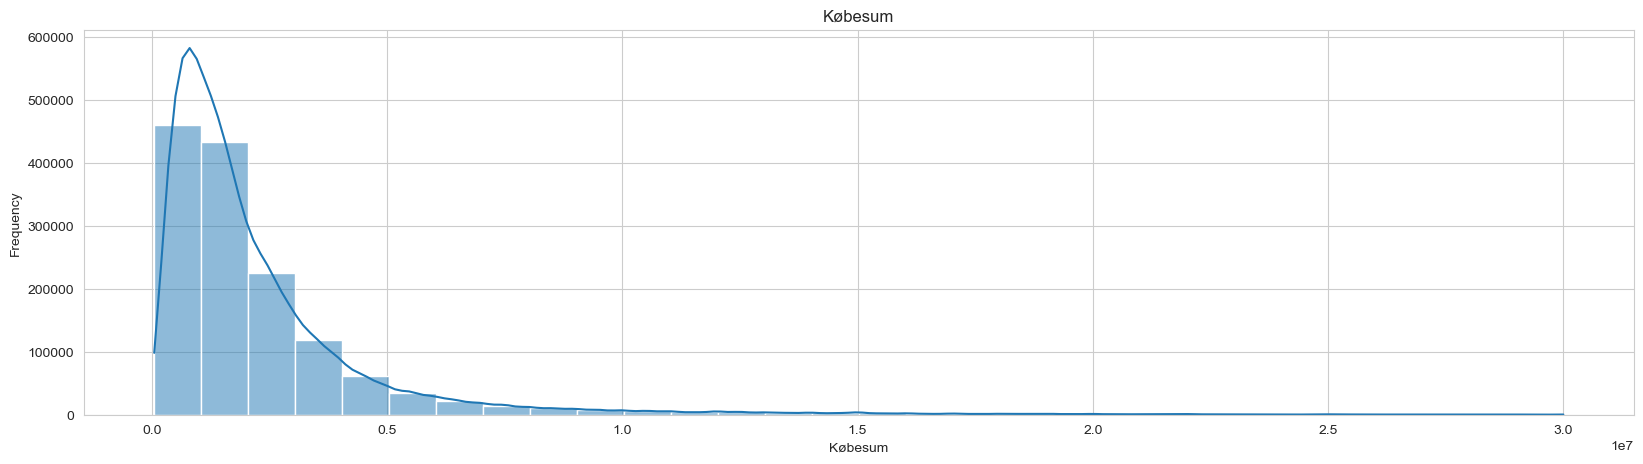

In [ ]:
# as we can image the distribution of the many of our variables is right-skewed
plt.figure(figsize=(20, 5))

sns.histplot(df_cleaned['Købesum'], kde=True, bins=30)
plt.title('Købesum')
plt.xlabel('Købesum')
plt.ylabel('Frequency')


plt.show()

In [ ]:
#here is some code to find the right skewed columns and log normalize them, i chose not to do it since it introduces a lot of hassle, and only gives a small improvement as far as i believe
#numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

#skewed_cols = df_cleaned[numerical_cols].skew()

#highly_skewed = skewed_cols[skewed_cols > 0.85]

#print(highly_skewed)

#skewed_features = highly_skewed.index.tolist()

In [ ]:
# Apply the log transform to the identified skewed features
#for col in skewed_features:
#    df_cleaned[col + 'log'] = np.log1p(df_cleaned[col])


In [113]:
#here i also make 2 new features, age of the property and date_ordinal, which is the number of days since the first date in the dataset

df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.startswith('num')]
df_cleaned = df_cleaned.sort_values('dato')
df_cleaned= df_cleaned.set_index('dato')
df_cleaned.index = pd.to_datetime(df_cleaned.index)
df_cleaned['age'] = df_cleaned.index.year - df_cleaned['Byggeår']
df_cleaned['date_ordinal'] = (df_cleaned.index - df_cleaned.index.min()).days

In [106]:
df_cleaned.columns # here i did some correlation matrix to see what features are most important for predicting the price




Index(['Købesum', 'Vær.', 'm2', 'pris_pr_m2_mean_30D_by',
       'pris_pr_m2_mean_180D_by', 'pris_pr_m2_mean_365D_by',
       'pris_pr_m2_mean_30D_postnummer', 'pris_pr_m2_mean_180D_postnummer',
       'pris_pr_m2_mean_365D_postnummer', 'pris_pr_m2_mean_30D_område',
       'pris_pr_m2_mean_180D_område', 'pris_pr_m2_mean_365D_område',
       'pris_pr_m2_mean_30D_region', 'pris_pr_m2_mean_180D_region',
       'pris_pr_m2_mean_365D_region', 'mean_of_5_neighbors_pris_pr_m2',
       'std_of_5_neighbors_pris_pr_m2', 'mean_of_10_neighbors_pris_pr_m2',
       'std_of_10_neighbors_pris_pr_m2', 'mean_of_25_neighbors_pris_pr_m2',
       'std_of_25_neighbors_pris_pr_m2', 'mean_of_50_neighbors_pris_pr_m2',
       'std_of_50_neighbors_pris_pr_m2', 'område_Bornholm',
       'område_Fyn og øer', 'område_Hovedstaden, København',
       'område_Nordjylland', 'område_Nordsjælland', 'område_Sydjylland',
       'område_Øst- og Midtjylland', 'stype_Alm. Salg', 'stype_Andet',
       'stype_Auktion', 'stype_F

In [114]:
df_cleaned.to_csv("pretty_cleaned_data.csv")

In [ ]:
df_cleaned = pd.read_csv("pretty_cleaned_data.csv")

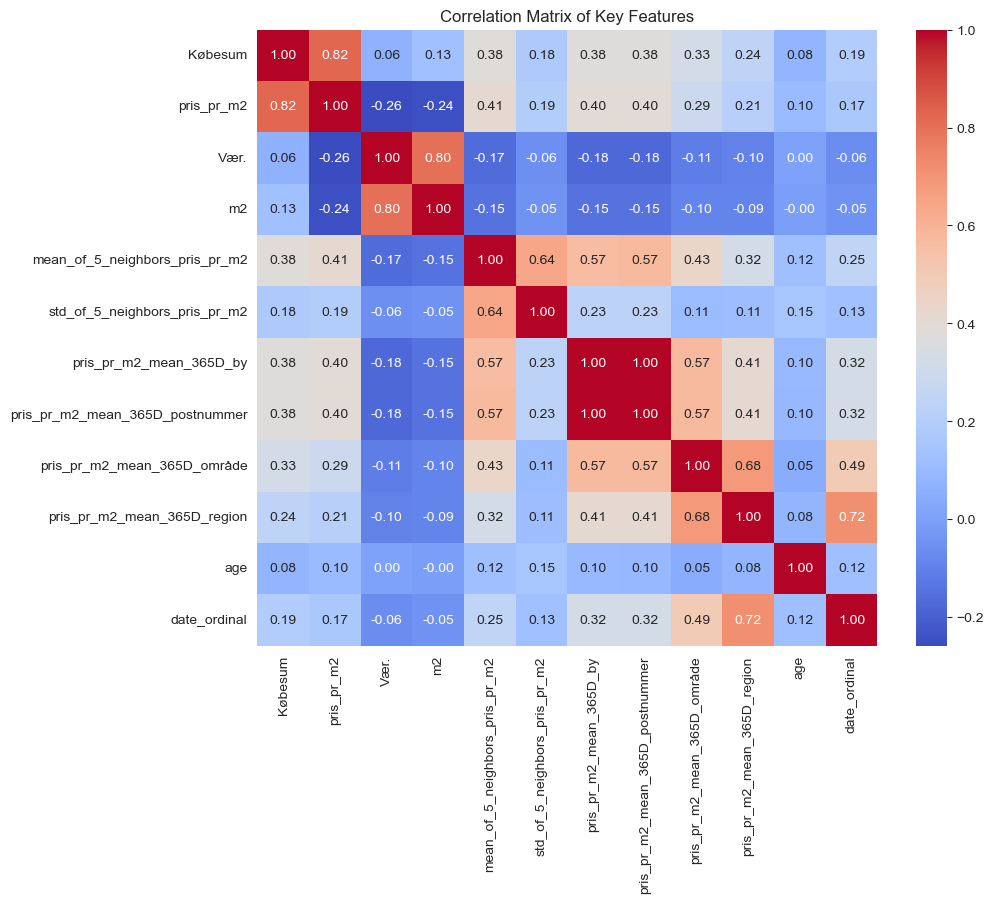

In [ ]:
#this was so i can see the best columns

numerical_cols_for_corr = [
    'Købesum',
    'pris_pr_m2',
    'Vær.',
    'm2',
    #'mean_of_10_neighbors_pris_pr_m2',
    #'mean_of_25_neighbors_pris_pr_m2', #all the same
    'mean_of_5_neighbors_pris_pr_m2',
    #'mean_of_50_neighbors_pris_pr_m2',
    #'std_of_10_neighbors_pris_pr_m2',
    #'std_of_25_neighbors_pris_pr_m2', #all the same
    'std_of_5_neighbors_pris_pr_m2',
    #'std_of_50_neighbors_pris_pr_m2',
    'pris_pr_m2_mean_365D_by',
    'pris_pr_m2_mean_365D_postnummer',
    'pris_pr_m2_mean_365D_område',
    'pris_pr_m2_mean_365D_region',
    #'pris_pr_m2_mean_30D_by',
    #'pris_pr_m2_mean_30D_postnummer',
    #'pris_pr_m2_mean_30D_område',
    #'pris_pr_m2_mean_30D_region', #longer better
    #'Byggeår',
   'age',
    'date_ordinal'
]
#putting away the bad
correlation_matrix = df_cleaned[numerical_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

In [ ]:
print(df_cleaned.dtypes)
df_cleaned = df_cleaned.drop(columns=['Byggeår', 'pris_pr_m2'])

Købesum                              int64
Vær.                                 int64
Byggeår                              int64
m2                                 float64
pris_pr_m2                         float64
pris_pr_m2_mean_30D_by             float64
pris_pr_m2_mean_180D_by            float64
pris_pr_m2_mean_365D_by            float64
pris_pr_m2_mean_30D_postnummer     float64
pris_pr_m2_mean_180D_postnummer    float64
pris_pr_m2_mean_365D_postnummer    float64
pris_pr_m2_mean_30D_område         float64
pris_pr_m2_mean_180D_område        float64
pris_pr_m2_mean_365D_område        float64
pris_pr_m2_mean_30D_region         float64
pris_pr_m2_mean_180D_region        float64
pris_pr_m2_mean_365D_region        float64
mean_of_5_neighbors_pris_pr_m2     float64
std_of_5_neighbors_pris_pr_m2      float64
mean_of_10_neighbors_pris_pr_m2    float64
std_of_10_neighbors_pris_pr_m2     float64
mean_of_25_neighbors_pris_pr_m2    float64
std_of_25_neighbors_pris_pr_m2     float64
mean_of_50_

In [ ]:
# i also did this to find the best features

def calculate_mi_scores(df, target_column):
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    mi_scores = mutual_info_regression(X, y)

    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

scores = calculate_mi_scores(df_cleaned, 'Købesum')
print(scores)

pris_pr_m2                         4.081831
mean_of_5_neighbors_pris_pr_m2     0.848215
mean_of_10_neighbors_pris_pr_m2    0.836420
mean_of_50_neighbors_pris_pr_m2    0.832576
mean_of_25_neighbors_pris_pr_m2    0.832446
pris_pr_m2_mean_365D_by            0.820409
pris_pr_m2_mean_365D_postnummer    0.817010
pris_pr_m2_mean_180D_by            0.816871
pris_pr_m2_mean_180D_postnummer    0.811746
pris_pr_m2_mean_30D_by             0.806158
pris_pr_m2_mean_30D_postnummer     0.792437
pris_pr_m2_mean_365D_område        0.694994
pris_pr_m2_mean_180D_område        0.685670
pris_pr_m2_mean_30D_område         0.660593
std_of_50_neighbors_pris_pr_m2     0.613945
std_of_25_neighbors_pris_pr_m2     0.612864
std_of_10_neighbors_pris_pr_m2     0.608095
std_of_5_neighbors_pris_pr_m2      0.601395
pris_pr_m2_mean_365D_region        0.581913
pris_pr_m2_mean_180D_region        0.575796
pris_pr_m2_mean_30D_region         0.558741
date_ordinal                       0.485009
age                             

In [ ]:
#removed some 
df_cleaned = df_cleaned.drop(columns=['pris_pr_m2_mean_30D_by', 'pris_pr_m2_mean_30D_postnummer',
       'pris_pr_m2_mean_30D_område', 'pris_pr_m2_mean_30D_region','pris_pr_m2_mean_180D_by',
       'pris_pr_m2_mean_180D_postnummer', 'pris_pr_m2_mean_180D_område',
       'pris_pr_m2_mean_180D_region', 'mean_of_10_neighbors_pris_pr_m2','mean_of_25_neighbors_pris_pr_m2',
       'mean_of_50_neighbors_pris_pr_m2', 'std_of_10_neighbors_pris_pr_m2',
       'std_of_25_neighbors_pris_pr_m2', 'std_of_50_neighbors_pris_pr_m2',])

In [60]:
df_cleaned.columns

Index(['Købesum', 'Vær.', 'm2', 'pris_pr_m2_mean_365D_by',
       'pris_pr_m2_mean_365D_postnummer', 'pris_pr_m2_mean_365D_område',
       'pris_pr_m2_mean_365D_region', 'mean_of_5_neighbors_pris_pr_m2',
       'std_of_5_neighbors_pris_pr_m2', 'område_Bornholm', 'område_Fyn og øer',
       'område_Hovedstaden, København', 'område_Nordjylland',
       'område_Nordsjælland', 'område_Sydjylland',
       'område_Øst- og Midtjylland', 'stype_Alm. Salg', 'stype_Andet',
       'stype_Auktion', 'stype_Fam. Salg', 'btype_Fritidshus',
       'btype_Landejendom', 'btype_Rækkehus', 'btype_Villa', 'age',
       'date_ordinal'],
      dtype='object')

In [55]:
df_cleaned.to_csv("cleaned_data.csv")

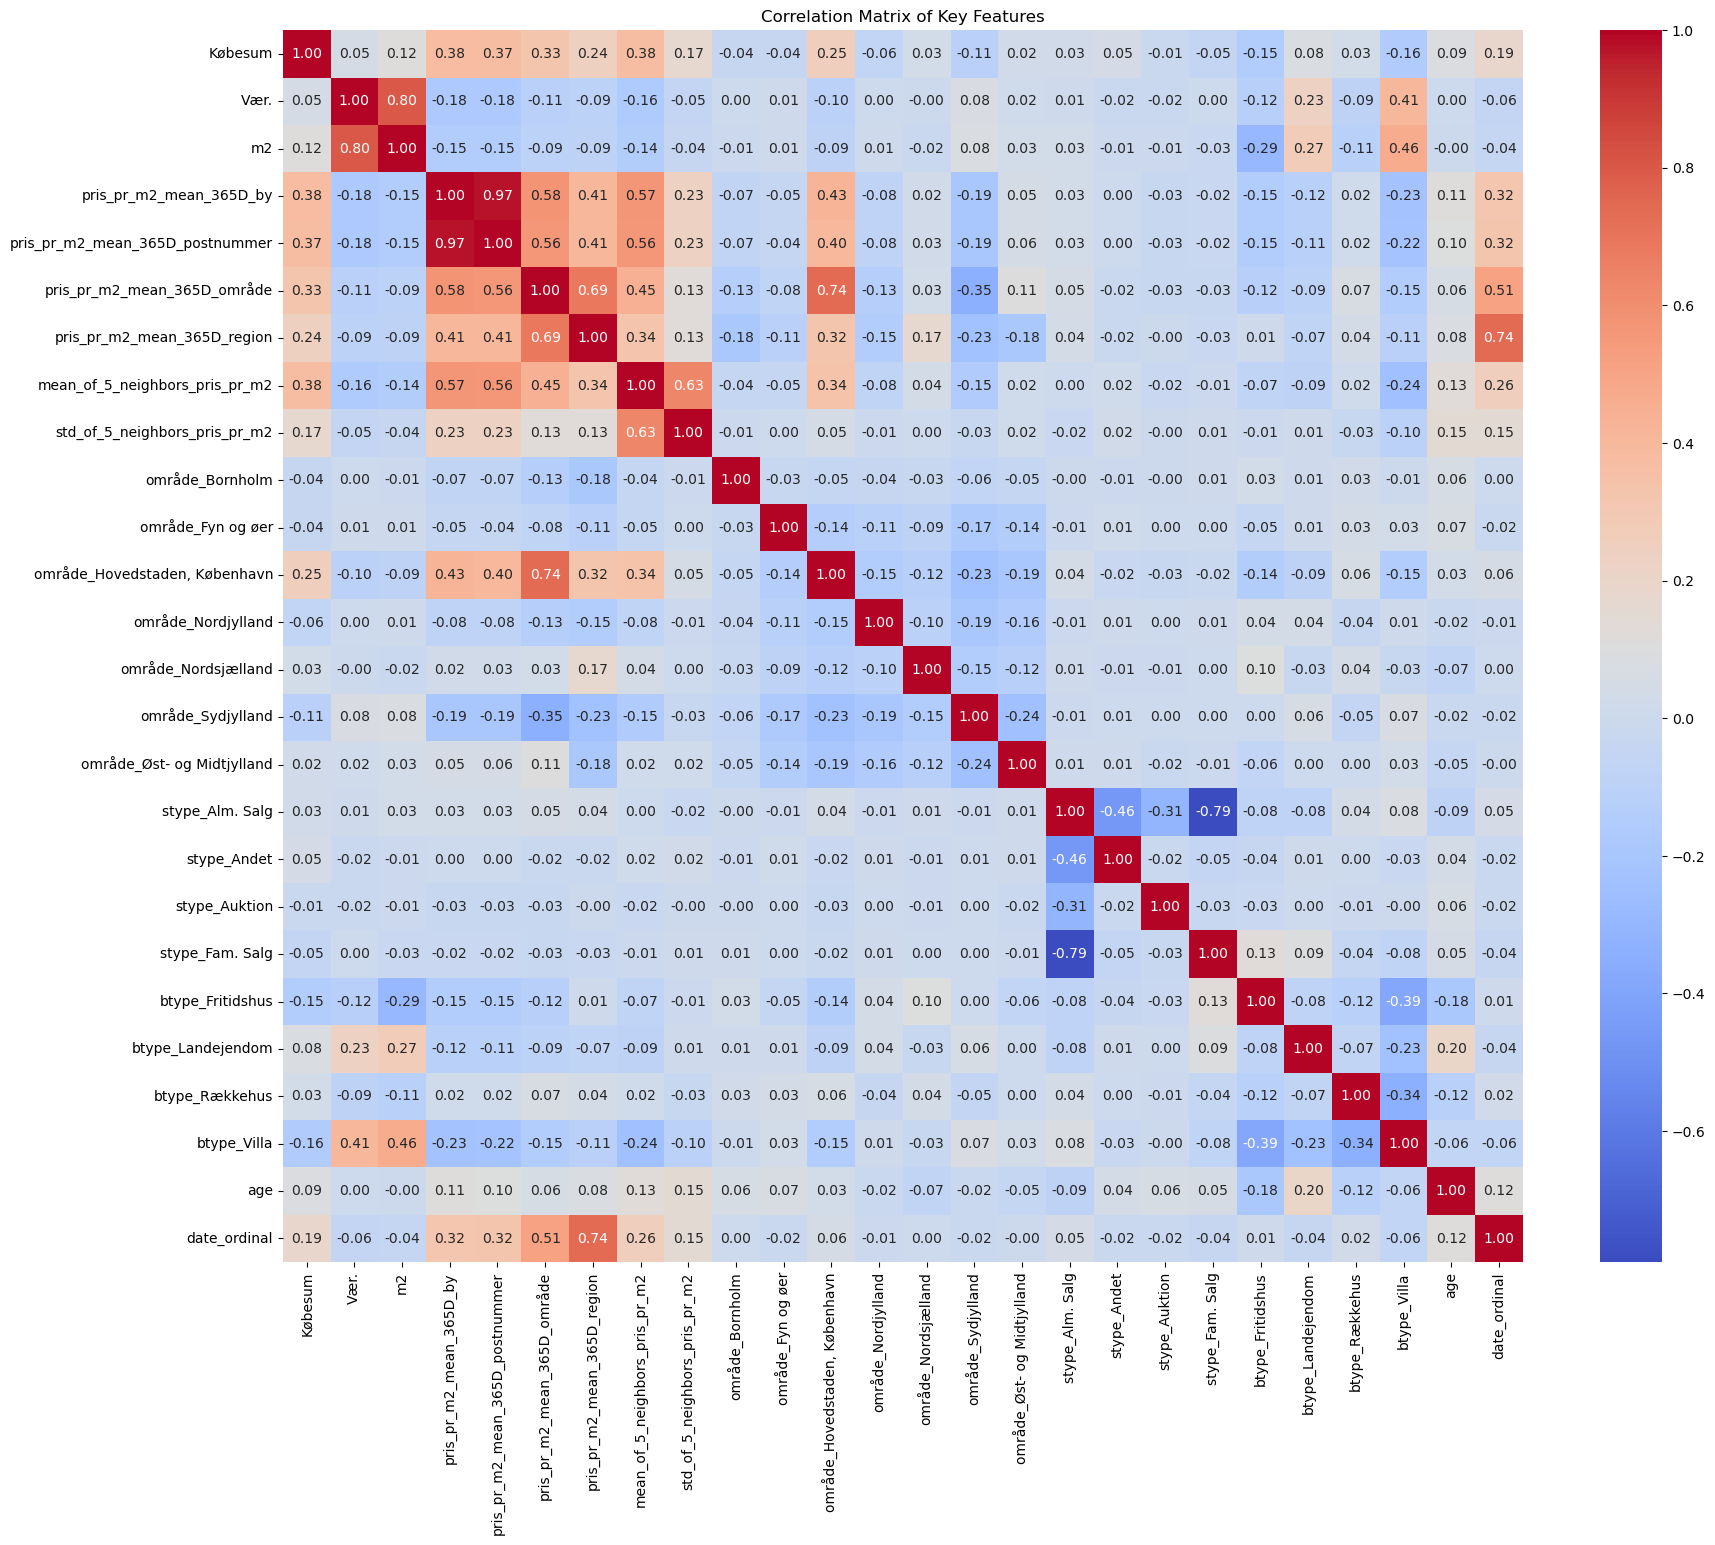

In [59]:

#putting away the bad
correlation_matrix = df_cleaned.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

In [ ]:
scores = calculate_mi_scores(df_cleaned, 'Købesum')
print(scores)
# did it again for whatever reason

In [ ]:
df_cleaned = df_cleaned.drop(columns=['stype_Andet', 'stype_Fam. Salg', 'stype_Auktion', 'stype_Alm. Salg','pris_pr_m2_mean_365D_region', 'pris_pr_m2_mean_365D_område', 'pris_pr_m2_mean_365D_by'])
# chose to remove more

In [64]:
df_cleaned.to_csv("cleaned_data_harsh.csv")

In [ ]:
df_cleaned= pd.read_csv("cleaned_data_harsh.csv")


In [ ]:
df_cleaned['mean_of_5_neighbors_pris']= df_cleaned['m2']* df_cleaned['mean_of_5_neighbors_pris_pr_m2']
#made a new feature, which is the m2 * the best estimater for square price

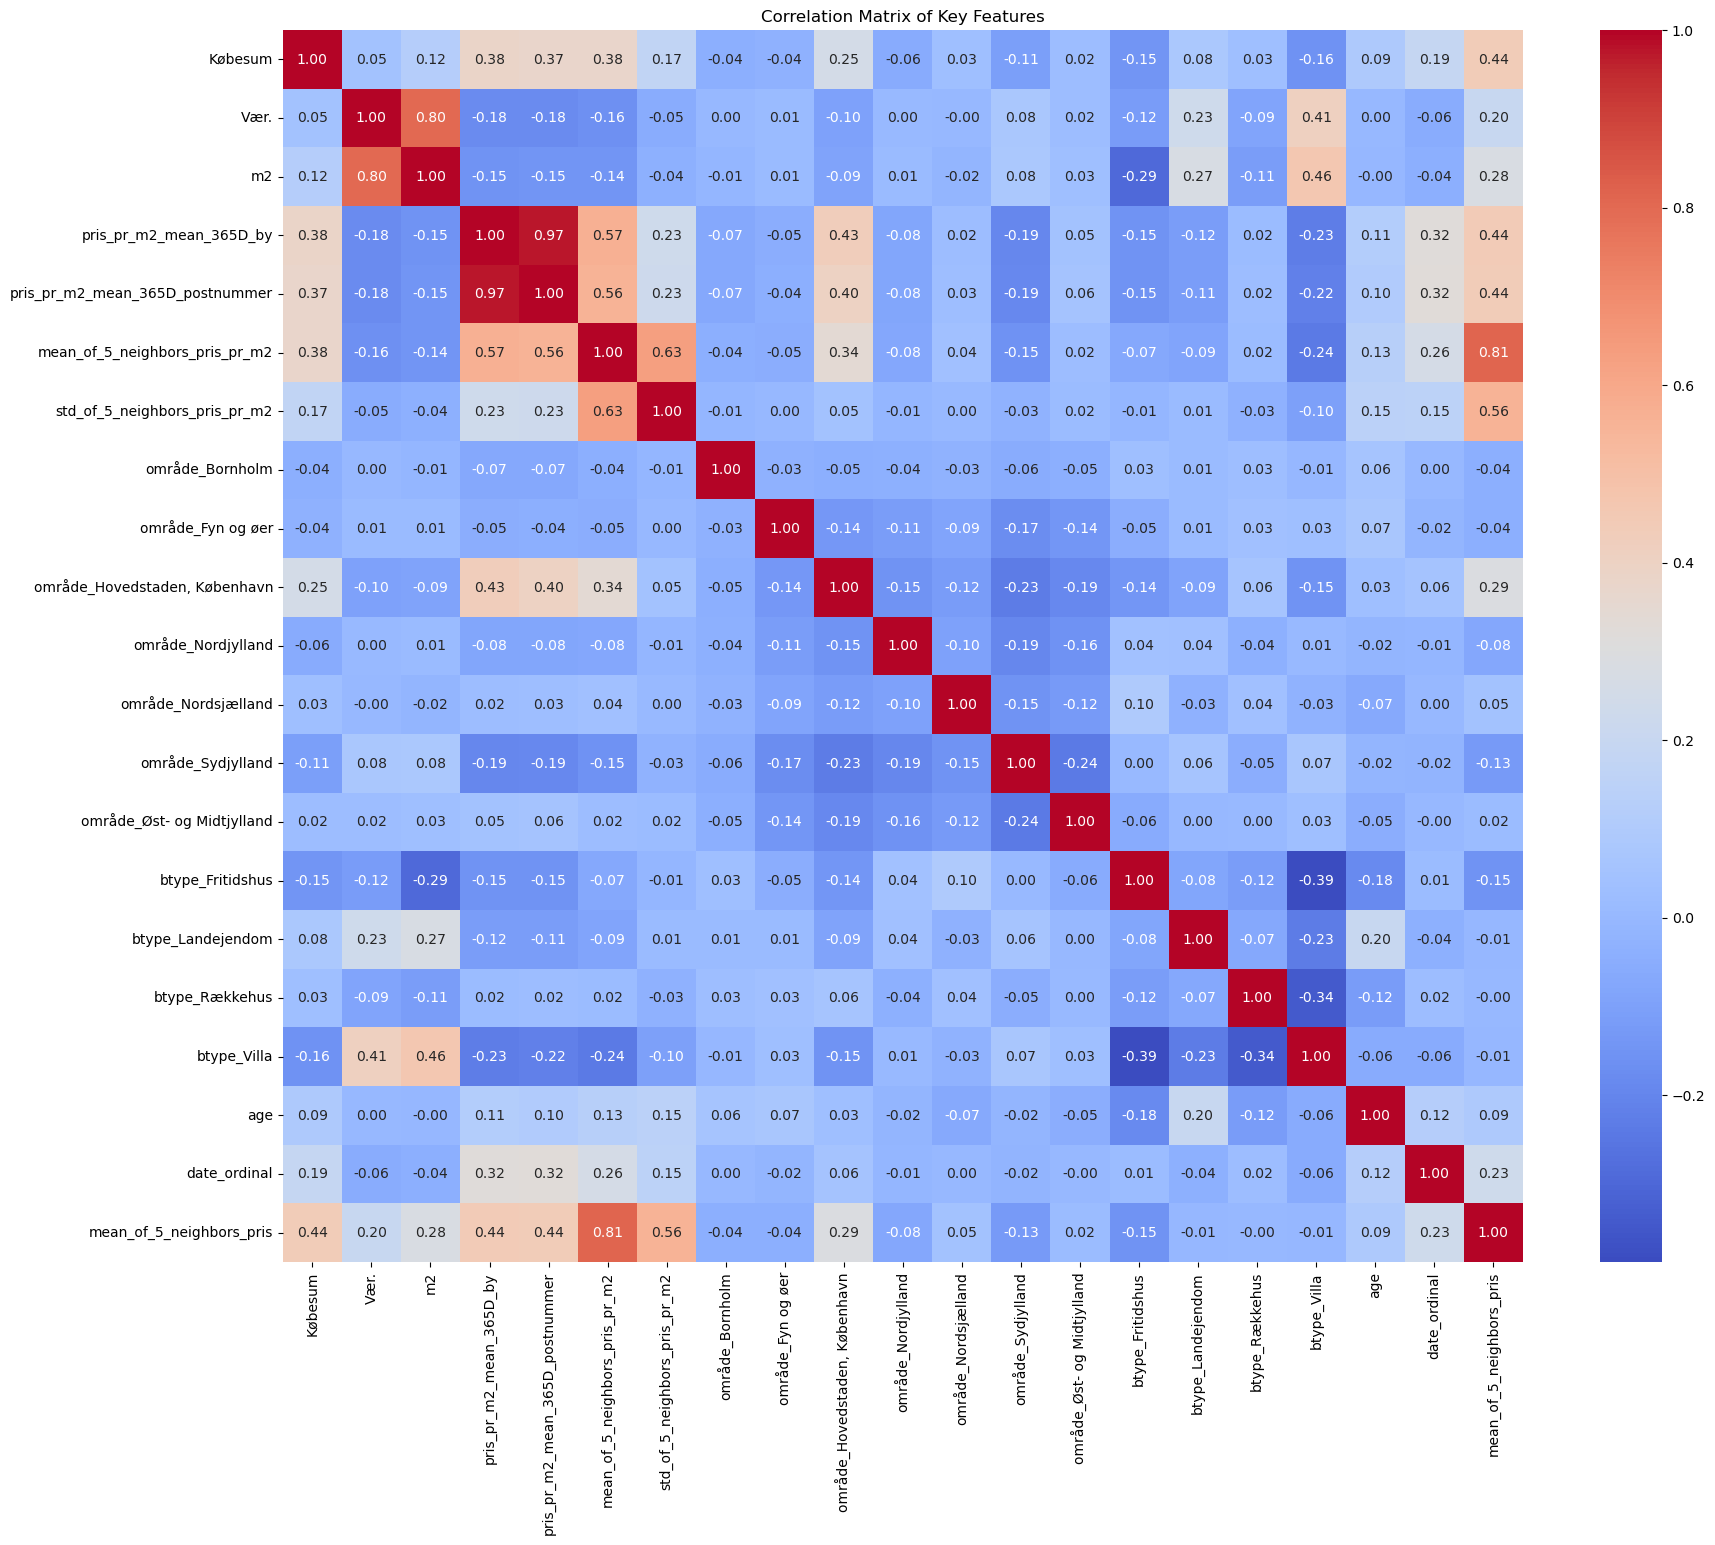

In [ ]:
#putting away the bad
correlation_matrix = df_cleaned.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

# honestly i could remove more features but i am going to wait to see what you say

In [120]:
df_cleaned.to_csv("cleaned_data_harsh.csv")

overall mape: 67.9%


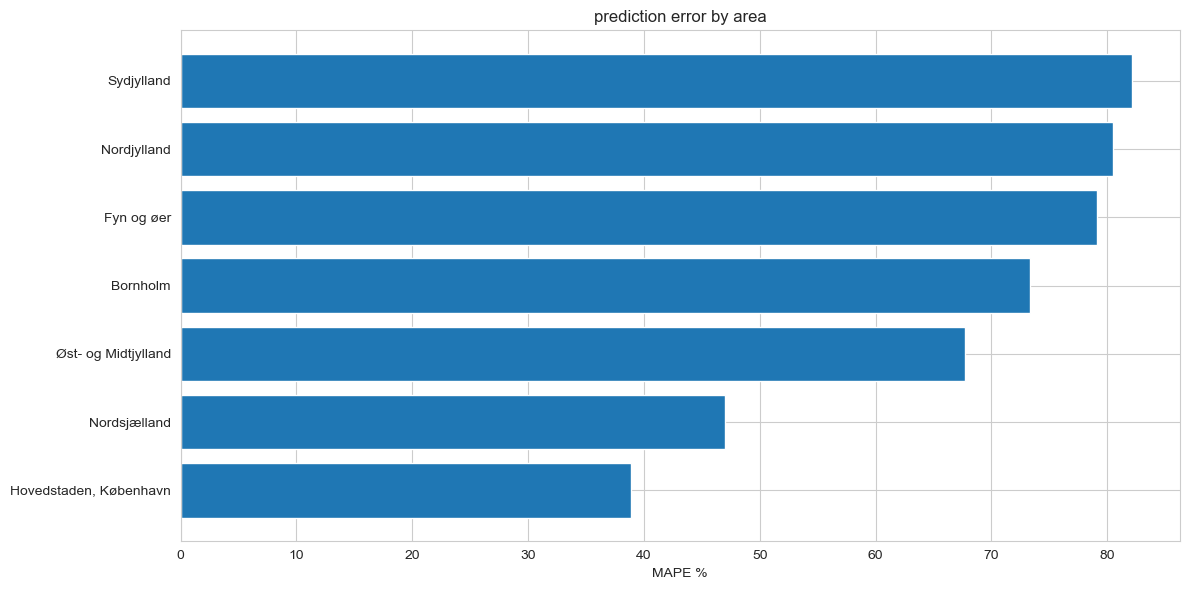

In [122]:
# just checking how good the nn times price is by area
df_cleaned = pd.read_csv("cleaned_data_harsh.csv")

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df_cleaned['Købesum']
pred = df_cleaned['mean_of_5_neighbors_pris']

# clean up the data
clean_data = df_cleaned.dropna(subset=['Købesum', 'mean_of_5_neighbors_pris'])

print(f"overall mape: {mape(clean_data['Købesum'], clean_data['mean_of_5_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['Købesum'], area_data['mean_of_5_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()